# RoBERTa Subjectivity Training

- Train on `corpus_training_hn.csv`, `corpus_training_kaggle.csv`, or both
- Evaluate on `corpus_evaluation.csv`
- Save model, confusion matrix, and metrics CSV

In [12]:
!pip -q install -U "transformers[torch]" datasets accelerate scikit-learn "pandas>=2.2.2,<3" matplotlib seaborn openpyxl torchview torchviz graphviz

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import libraries

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
import os
import warnings
from transformers import logging as transformers_logging

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## Configurations

In [15]:
TEXT_COL = 'text_transformer'
LABEL_COL = 'label_subjectivity'

LABEL2ID = {'Objective': 0, 'Subjective': 1}
ID2LABEL = {idx: label for label, idx in LABEL2ID.items()}

BASE_DIR = Path('/content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project')
TRAIN_HN_CSV = BASE_DIR / 'data/preprocessed-data/corpus_training_hn.csv'
TRAIN_KAGGLE_CSV = BASE_DIR / 'data/preprocessed-data/corpus_training_kaggle.csv'
EVAL_CSV = BASE_DIR / 'data/preprocessed-data/corpus_evaluation.csv'
OUTPUT_DIR = BASE_DIR / 'outputs/roberta_subjectivity_combined'

TRAIN_MODE = 'combined'
MODEL_NAME = 'roberta-base'  # loads pretrained Facebook AI RoBERTa weights
MAX_LENGTH = 384
SEED = 42
LEARNING_RATE = 1e-5
NUM_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 2

USE_WEIGHTED_LOSS = True
USE_OVERSAMPLING = False
IMBALANCE_RATIO_THRESHOLD = 1.5

## Data Preparation

- Loads training data
- Standardises labels
- Splits train and validation sets
- Optionally applies oversampling

In [16]:
# Load training data
cap_map = {'objective': 'Objective', 'subjective': 'Subjective'}


def load_training_csv(path, text_col, label_col, source_name):
    df = pd.read_csv(path)
    df = df[[text_col, label_col]].dropna().copy()
    df[text_col] = df[text_col].astype(str).str.strip()
    df[label_col] = df[label_col].astype(str).str.strip().replace(cap_map)
    df = df.rename(columns={text_col: TEXT_COL, label_col: LABEL_COL})
    df['source'] = source_name
    return df


if TRAIN_MODE == 'combined':
    parts = [
        load_training_csv(TRAIN_HN_CSV, TEXT_COL, LABEL_COL, 'hn'),
        load_training_csv(TRAIN_KAGGLE_CSV, TEXT_COL, LABEL_COL, 'kaggle'),
    ]
elif TRAIN_MODE == 'hn_only':
    parts = [
        load_training_csv(TRAIN_HN_CSV, TEXT_COL, LABEL_COL, 'hn'),
    ]
else:
    parts = [
        load_training_csv(TRAIN_KAGGLE_CSV, TEXT_COL, LABEL_COL, 'kaggle'),
    ]

df = pd.concat(parts, ignore_index=True)
df['labels'] = df[LABEL_COL].map(LABEL2ID)

source_counts = df['source'].value_counts()
source_ratio = source_counts.max() / source_counts.min() if len(source_counts) > 1 else 1.0
label_counts = df[LABEL_COL].value_counts().reindex(LABEL2ID.keys(), fill_value=0)

print(f'Train mode: {TRAIN_MODE}')
print(f'Total rows: {len(df)}')
print('Source counts:')
print(source_counts)
print(f'Source ratio: {source_ratio:.2f}')
print('Label counts:')
print(label_counts)

train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED,
    stratify=df['labels'],
)

print(f'\nTrain rows: {len(train_df)}')
print(f'Validation rows: {len(val_df)}')

Train mode: combined
Total rows: 50899
Source counts:
source
kaggle    50000
hn          899
Name: count, dtype: int64
Source ratio: 55.62
Label counts:
label_subjectivity
Objective     12953
Subjective    37946
Name: count, dtype: int64

Train rows: 45809
Validation rows: 5090


## Oversampling check

In [17]:
train_label_counts = train_df[LABEL_COL].value_counts().reindex(LABEL2ID.keys(), fill_value=0)
train_non_zero = train_label_counts[train_label_counts > 0]
train_ratio = float(train_non_zero.max() / train_non_zero.min())

print(f'Train imbalance ratio before oversampling: {train_ratio:.2f}')
print('Imbalance ratio threshold:', IMBALANCE_RATIO_THRESHOLD)

Train imbalance ratio before oversampling: 2.93
Imbalance ratio threshold: 1.5


## Tokenisation

- Converts text data into tokenized Hugging Face datasets and computes class weights from the training split

In [18]:
def tokenize_datasets(train_df, val_df, model_name=MODEL_NAME, max_length=MAX_LENGTH):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def to_dataset(frame):
        ds = Dataset.from_pandas(frame[[TEXT_COL, 'labels']].reset_index(drop=True))
        ds = ds.rename_column('labels', 'label')
        return ds.map(
            lambda x: tokenizer(x[TEXT_COL], truncation=True, max_length=max_length),
            batched=True,
            remove_columns=[TEXT_COL],
        )

    train_tok = to_dataset(train_df)
    val_tok = to_dataset(val_df)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    return tokenizer, train_tok, val_tok, data_collator


def compute_class_weights(train_df):
    counts = train_df['labels'].value_counts().sort_index()
    num_classes = len(LABEL2ID)
    inv = (counts.sum() / (num_classes * counts)).astype(float)
    weights = np.sqrt(inv).values
    class_weights = torch.tensor(weights, dtype=torch.float)
    print('Class counts:', counts.to_dict())
    print('Class weights (Objective, Subjective):', class_weights.tolist())
    return class_weights

## Training pipeline

- The polarity pipeline uses a pretrained RoBERTa checkpoint from Hugging Face, `from_pretrained` loads the real encoder weights for robert-a.
- Training minimises cross-entropy, and when `use_weighted_loss=True`, the loss is class-weighted via the Trainer subclass (ClassWeightedTrainer) so minority polarity classes contribute more to the gradient. 
- TrainingArguments are set with `load_best_model_at_end=True` and `metric_for_best_model='f1_macro'` so after training, the Trainer reloads the checkpoint from the best validation macro-F1 epoch before the model is saved.
- EarlyStoppingCallback ends training if validation macro-F1 fails to improve for `EARLY_STOPPING_PATIENCE` consecutive evaluation rounds.

In [ ]:
class ClassWeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, use_weighted_loss=False, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights
        self._use_weighted_loss = use_weighted_loss

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs['labels']
        outputs = model(**{k: v for k, v in inputs.items() if k != 'labels'})
        logits = outputs['logits']

        loss = F.cross_entropy(logits, labels)
        if self._use_weighted_loss:
            loss = F.cross_entropy(logits, labels, weight=self._class_weights.to(logits.device))

        return (loss, outputs) if return_outputs else loss


def build_training_args(output_dir):
    return TrainingArguments(
        output_dir=str(output_dir),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_steps=200,
        save_total_limit=3,
        seed=SEED,
        fp16=torch.cuda.is_available(),
        report_to='none',
        max_grad_norm=1.0,
    )


def build_model(model_name=MODEL_NAME):
    return AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(LABEL2ID),
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )


def compute_metrics(eval_pred):
    if hasattr(eval_pred, 'predictions'):
        logits, labels = eval_pred.predictions, eval_pred.label_ids
    else:
        logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision_macro': prec_m,
        'recall_macro': rec_m,
        'f1_macro': f1_m,
        'precision_weighted': prec_w,
        'recall_weighted': rec_w,
        'f1_weighted': f1_w,
    }


def build_trainer(model, tokenizer, train_tok, val_tok, data_collator, class_weights, use_weighted_loss, output_dir):
    return ClassWeightedTrainer(
        model=model,
        args=build_training_args(output_dir),
        train_dataset=train_tok,
        eval_dataset=val_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        use_weighted_loss=use_weighted_loss,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )


def train_experiment(train_df, val_df, output_dir, use_weighted_loss, use_oversampling=False):
    tokenizer, train_tok, val_tok, data_collator = tokenize_datasets(train_df, val_df)
    class_weights = compute_class_weights(train_df)
    model = build_model()
    trainer = build_trainer(
        model,
        tokenizer,
        train_tok,
        val_tok,
        data_collator,
        class_weights,
        use_weighted_loss,
        output_dir,
    )

    print('Trainer configured with:')
    print(' - learning_rate:', LEARNING_RATE)
    print(' - num_epochs:', NUM_EPOCHS)
    print(' - max_length:', MAX_LENGTH)
    print(' - weighted_loss:', use_weighted_loss)
    print(' - oversampling:', use_oversampling)
    print()

    train_result = trainer.train()
    print(train_result)

    output_dir.mkdir(parents=True, exist_ok=True)
    trainer.save_model(output_dir / 'final_model')
    tokenizer.save_pretrained(output_dir / 'final_model')
    print(f'Saved model to {output_dir / "final_model"}')
    return {
        'trainer': trainer,
        'model': trainer.model,
        'tokenizer': tokenizer,
        'train_result': train_result,
        'train_df': train_df,
        'val_df': val_df,
        'output_dir': output_dir,
    }

## Evaluation Function

In [20]:
def evaluate_on_csv(model, tokenizer, output_dir, eval_csv=EVAL_CSV, gold_col='label_subjectivity'):
    eval_raw = pd.read_csv(eval_csv, encoding='utf-8')
    eval_df = eval_raw[[TEXT_COL, gold_col]].dropna().copy()
    eval_df[TEXT_COL] = eval_df[TEXT_COL].astype(str).str.strip()
    eval_df[gold_col] = eval_df[gold_col].astype(str).str.strip().replace(cap_map)

    y_true = eval_df[gold_col].map(LABEL2ID).values
    texts = eval_df[TEXT_COL].tolist()

    model.eval()
    device = next(model.parameters()).device
    batch_size = 32
    all_logits = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors='pt',
            ).to(device)
            logits = model(**enc).logits.cpu().numpy()
            all_logits.append(logits)

    logits = np.vstack(all_logits)
    y_pred = logits.argmax(axis=-1)

    # Save evaluation predictions with requested columns
    pred_export = eval_raw[[c for c in ['doc_id', 'object_id', 'text'] if c in eval_raw.columns]].copy()
    pred_export['pred_subjectivity'] = [ID2LABEL[i] for i in y_pred]
    pred_export_csv = output_dir / 'roberta_eval_predictions.csv'
    output_dir.mkdir(parents=True, exist_ok=True)
    pred_export.to_csv(pred_export_csv, index=False)
    print(f'Saved predictions: {pred_export_csv}')

    target_names = [ID2LABEL[i] for i in range(len(ID2LABEL))]
    labels_order = list(range(len(LABEL2ID)))

    print('=' * 60)
    print('Evaluation on corpus_evaluation.csv')
    print('=' * 60)
    print(f'N (samples): {len(y_true)}')
    print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
    print()

    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_order, average=None, zero_division=0
    )
    metrics_rows = []
    for i, name in enumerate(target_names):
        metrics_rows.append(
            {'class': name, 'precision': prec[i], 'recall': rec[i], 'f1': f1[i], 'support': int(sup[i])}
        )
    metrics_df = pd.DataFrame(metrics_rows)
    for c in ('precision', 'recall', 'f1'):
        metrics_df[c] = metrics_df[c].round(4)

    eval_total_support = int(len(y_true))
    summary_rows = []
    for avg in ('macro', 'weighted'):
        p_a, r_a, f_a, _ = precision_recall_fscore_support(
            y_true, y_pred, average=avg, zero_division=0
        )
        summary_rows.append(
            {
                'average_type': avg,
                'precision': p_a,
                'recall': r_a,
                'f1': f_a,
                'support': eval_total_support,
            }
        )
    summary_df = pd.DataFrame(summary_rows)
    for c in ('precision', 'recall', 'f1'):
        summary_df[c] = summary_df[c].round(4)

    print('Subjectivity classification report:')
    print(
        classification_report(
            y_true,
            y_pred,
            labels=labels_order,
            target_names=target_names,
            digits=4,
            zero_division=0,
        )
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels_order)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names,
        ax=ax,
        cbar_kws={'label': 'Count'},
    )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title('RoBERTa Subjectivity Confusion Matrix')
    plt.tight_layout()
    plt.show()

    cm_path = output_dir / 'roberta_confusion_matrix_eval.png'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(cm_path, dpi=150, bbox_inches='tight')
    print(f'\nSaved figure: {cm_path}')

    part_per = metrics_df.copy()
    part_per.insert(0, 'scope', 'per_class')
    part_per = part_per.rename(columns={'class': 'name'})
    part_per = part_per[['scope', 'name', 'precision', 'recall', 'f1', 'support']]

    part_agg = summary_df.copy()
    part_agg['scope'] = part_agg['average_type']
    part_agg['name'] = part_agg['average_type']
    part_agg = part_agg.drop(columns=['average_type'])
    part_agg = part_agg[['scope', 'name', 'precision', 'recall', 'f1', 'support']]

    eval_metrics_csv = output_dir / 'roberta_eval_metrics.csv'
    pd.concat([part_per, part_agg], ignore_index=True).to_csv(eval_metrics_csv, index=False)
    print(f'Saved metrics: {eval_metrics_csv}')

    return {
        'eval_df': eval_df,
        'y_true': y_true,
        'y_pred': y_pred,
        'metrics_df': metrics_df,
        'summary_df': summary_df,
        'confusion_matrix': cm,
    }

## Run Experiments

In [23]:
def run_experiment(
    run_name,
    train_mode=TRAIN_MODE,
    output_dir=OUTPUT_DIR,
    use_weighted_loss=USE_OVERSAMPLING,
    use_oversampling=None,
    train_df=train_df,
    val_df=val_df,
):
    print('Running experiment:', run_name)

    if use_oversampling:
        target = train_df[LABEL_COL].value_counts().max()
        oversampled_parts = []
        for _, group in train_df.groupby(LABEL_COL, sort=False):
            oversampled_parts.append(group.sample(n=target, replace=len(group) < target, random_state=SEED))
        train_df = pd.concat(oversampled_parts, ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
        train_df['labels'] = train_df[LABEL_COL].map(LABEL2ID)
        print('Label counts after oversampling:')
        print(train_df[LABEL_COL].value_counts().reindex(LABEL2ID.keys(), fill_value=0))

    return train_experiment(
        train_df,
        val_df,
        output_dir=output_dir,
        use_weighted_loss=use_weighted_loss,
        use_oversampling=use_oversampling,
    )

Running experiment: roberta_subjectivity_baseline


Map:   0%|          | 0/45809 [00:00<?, ? examples/s]

Map:   0%|          | 0/5090 [00:00<?, ? examples/s]

Class counts: {0: 11658, 1: 34151}
Class weights (Objective, Subjective): [1.401678442955017, 0.8189524412155151]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

{'loss': '0.003002', 'grad_norm': '0.0002905', 'learning_rate': '3.995e-06', 'epoch': '3.003'}
{'loss': '2.455e-05', 'grad_norm': '0.0002686', 'learning_rate': '3.855e-06', 'epoch': '3.073'}
{'loss': '0.001211', 'grad_norm': '1.22', 'learning_rate': '3.716e-06', 'epoch': '3.142'}
{'loss': '0.0008705', 'grad_norm': '0.000484', 'learning_rate': '3.576e-06', 'epoch': '3.212'}
{'loss': '0.004582', 'grad_norm': '0.000279', 'learning_rate': '3.436e-06', 'epoch': '3.282'}
{'loss': '0.0005322', 'grad_norm': '1.043', 'learning_rate': '3.297e-06', 'epoch': '3.352'}
{'loss': '1.376e-05', 'grad_norm': '0.0001856', 'learning_rate': '3.157e-06', 'epoch': '3.422'}
{'loss': '0.00197', 'grad_norm': '0.0001909', 'learning_rate': '3.017e-06', 'epoch': '3.492'}
{'loss': '0.0003863', 'grad_norm': '0.0002075', 'learning_rate': '2.878e-06', 'epoch': '3.561'}
{'loss': '0.002906', 'grad_norm': '0.0001549', 'learning_rate': '2.738e-06', 'epoch': '3.631'}
{'loss': '2.596e-05', 'grad_norm': '0.0001227', 'learning

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '206.2', 'train_samples_per_second': '1111', 'train_steps_per_second': '69.46', 'train_loss': '0.008939', 'epoch': '4'}
TrainOutput(global_step=11456, training_loss=0.008939041998598324, metrics={'train_runtime': 206.1555, 'train_samples_per_second': 1111.03, 'train_steps_per_second': 69.462, 'train_loss': 0.008939041998598324, 'epoch': 4.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_baseline/final_model
Saved predictions: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_baseline/roberta_eval_predictions.csv
Evaluation on corpus_evaluation.csv
N (samples): 1000
Accuracy: 0.9420

Subjectivity classification report:
              precision    recall  f1-score   support

   Objective     0.8650    0.8480    0.8564       204
  Subjective     0.9613    0.9661    0.9637       796

    accuracy                         0.9420      1000
   macro avg     0.9131    0.9071    0.9100      1000
weighted avg     0.9416    0.9420    0.9418      1000



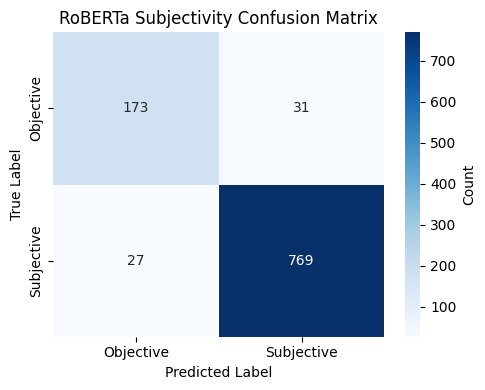


Saved figure: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_baseline/roberta_confusion_matrix_eval.png
Saved metrics: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_baseline/roberta_eval_metrics.csv
Running experiment: roberta_subjectivity_weighted_loss


Map:   0%|          | 0/45809 [00:00<?, ? examples/s]

Map:   0%|          | 0/5090 [00:00<?, ? examples/s]

Class counts: {0: 11658, 1: 34151}
Class weights (Objective, Subjective): [1.401678442955017, 0.8189524412155151]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

{'loss': '0.001288', 'grad_norm': '0.0002289', 'learning_rate': '3.995e-06', 'epoch': '3.003'}
{'loss': '6.581e-05', 'grad_norm': '0.0002179', 'learning_rate': '3.855e-06', 'epoch': '3.073'}
{'loss': '0.003643', 'grad_norm': '3.757', 'learning_rate': '3.716e-06', 'epoch': '3.142'}
{'loss': '0.003071', 'grad_norm': '0.003005', 'learning_rate': '3.576e-06', 'epoch': '3.212'}
{'loss': '0.004676', 'grad_norm': '0.0002971', 'learning_rate': '3.436e-06', 'epoch': '3.282'}
{'loss': '0.00142', 'grad_norm': '0.2548', 'learning_rate': '3.297e-06', 'epoch': '3.352'}
{'loss': '3.571e-05', 'grad_norm': '0.0001856', 'learning_rate': '3.157e-06', 'epoch': '3.422'}
{'loss': '3.074e-05', 'grad_norm': '0.0001745', 'learning_rate': '3.017e-06', 'epoch': '3.492'}
{'loss': '0.0004883', 'grad_norm': '0.0001698', 'learning_rate': '2.878e-06', 'epoch': '3.561'}
{'loss': '0.002399', 'grad_norm': '0.001315', 'learning_rate': '2.738e-06', 'epoch': '3.631'}
{'loss': '0.003049', 'grad_norm': '0.0002304', 'learning

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '255.8', 'train_samples_per_second': '895.3', 'train_steps_per_second': '55.97', 'train_loss': '0.009749', 'epoch': '4'}
TrainOutput(global_step=11456, training_loss=0.009748858369284637, metrics={'train_runtime': 255.8327, 'train_samples_per_second': 895.292, 'train_steps_per_second': 55.974, 'train_loss': 0.009748858369284637, 'epoch': 4.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_weighted_loss/final_model
Saved predictions: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_weighted_loss/roberta_eval_predictions.csv
Evaluation on corpus_evaluation.csv
N (samples): 1000
Accuracy: 0.9430

Subjectivity classification report:
              precision    recall  f1-score   support

   Objective     0.8889    0.8235    0.8550       204
  Subjective     0.9556    0.9736    0.9645       796

    accuracy                         0.9430      1000
   macro avg     0.9222    0.8986    0.9097      1000
weighted avg     0.9420    0.9430    0.9422      1000



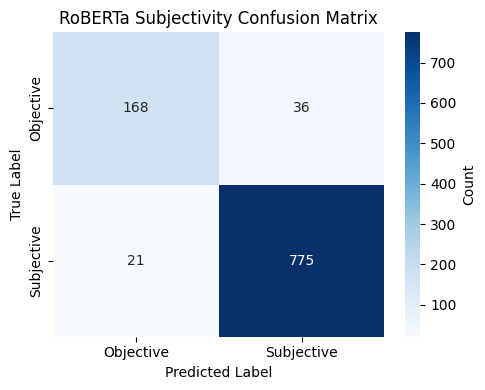


Saved figure: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_weighted_loss/roberta_confusion_matrix_eval.png
Saved metrics: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_weighted_loss/roberta_eval_metrics.csv
Running experiment: roberta_subjectivity_oversampling
Label counts after oversampling:
label_subjectivity
Objective     34151
Subjective    34151
Name: count, dtype: int64


Map:   0%|          | 0/68302 [00:00<?, ? examples/s]

Map:   0%|          | 0/5090 [00:00<?, ? examples/s]

Class counts: {0: 34151, 1: 34151}
Class weights (Objective, Subjective): [1.0, 1.0]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

{'loss': '1.486e-06', 'grad_norm': '3.56e-05', 'learning_rate': '1.942e-06', 'epoch': '4.029'}
{'loss': '3.233e-06', 'grad_norm': '3.584e-05', 'learning_rate': '1.849e-06', 'epoch': '4.076'}
{'loss': '1.221e-06', 'grad_norm': '3.406e-05', 'learning_rate': '1.755e-06', 'epoch': '4.123'}
{'loss': '1.189e-06', 'grad_norm': '3.006e-05', 'learning_rate': '1.661e-06', 'epoch': '4.17'}
{'loss': '1.149e-06', 'grad_norm': '3.134e-05', 'learning_rate': '1.568e-06', 'epoch': '4.216'}
{'loss': '1.102e-06', 'grad_norm': '3.02e-05', 'learning_rate': '1.474e-06', 'epoch': '4.263'}
{'loss': '1.057e-06', 'grad_norm': '3.202e-05', 'learning_rate': '1.38e-06', 'epoch': '4.31'}
{'loss': '1.277e-06', 'grad_norm': '3e-05', 'learning_rate': '1.286e-06', 'epoch': '4.357'}
{'loss': '9.203e-05', 'grad_norm': '2.901e-05', 'learning_rate': '1.193e-06', 'epoch': '4.404'}
{'loss': '9.581e-07', 'grad_norm': '2.866e-05', 'learning_rate': '1.099e-06', 'epoch': '4.451'}
{'loss': '1.015e-06', 'grad_norm': '2.847e-05', '

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '437', 'train_samples_per_second': '781.4', 'train_steps_per_second': '48.84', 'train_loss': '0.004654', 'epoch': '5'}
TrainOutput(global_step=21345, training_loss=0.00465434798457803, metrics={'train_runtime': 437.0275, 'train_samples_per_second': 781.438, 'train_steps_per_second': 48.841, 'train_loss': 0.00465434798457803, 'epoch': 5.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_oversampling/final_model
Saved predictions: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_oversampling/roberta_eval_predictions.csv
Evaluation on corpus_evaluation.csv
N (samples): 1000
Accuracy: 0.9340

Subjectivity classification report:
              precision    recall  f1-score   support

   Objective     0.9107    0.7500    0.8226       204
  Subjective     0.9387    0.9812    0.9595       796

    accuracy                         0.9340      1000
   macro avg     0.9247    0.8656    0.8910      1000
weighted avg     0.9330    0.9340    0.9315      1000



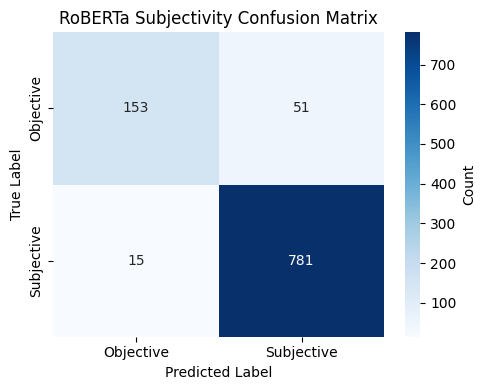


Saved figure: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_oversampling/roberta_confusion_matrix_eval.png
Saved metrics: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_oversampling/roberta_eval_metrics.csv
Finished runs: ['roberta_subjectivity_baseline', 'roberta_subjectivity_weighted_loss', 'roberta_subjectivity_oversampling']


In [24]:
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", category=UserWarning)
transformers_logging.set_verbosity_error()

experiment_setups = [
    {
        'run_name': 'roberta_subjectivity_baseline',
        'use_weighted_loss': False,
        'use_oversampling': False,
    },
    {
        'run_name': 'roberta_subjectivity_weighted_loss',
        'use_weighted_loss': True,
        'use_oversampling': False,
    },
    {
        'run_name': 'roberta_subjectivity_oversampling',
        'use_weighted_loss': False,
        'use_oversampling': True,
    },
]

all_run_results = {}

for setup in experiment_setups:
    run_output_dir = OUTPUT_DIR.parent / setup['run_name']
    experiment = run_experiment(
        run_name=setup['run_name'],
        train_mode=TRAIN_MODE,
        output_dir=run_output_dir,
        use_weighted_loss=setup['use_weighted_loss'],
        use_oversampling=setup['use_oversampling'],
        train_df=train_df,
        val_df=val_df,
    )
    results = evaluate_on_csv(experiment['model'], experiment['tokenizer'], experiment['output_dir'])

    all_run_results[setup['run_name']] = {
        'setup': setup,
        'output_dir': run_output_dir,
        'results': results,
    }

print('Finished runs:', list(all_run_results.keys()))

In [25]:
def _get_class_row(metrics_df, class_name):
    return metrics_df[metrics_df['class'] == class_name].iloc[0]

comparison_rows = []

for run_name, payload in all_run_results.items():
    results = payload['results']
    run_output_dir = payload['output_dir']

    macro_row = results['summary_df'][results['summary_df']['average_type'] == 'macro'].iloc[0]
    weighted_row = results['summary_df'][results['summary_df']['average_type'] == 'weighted'].iloc[0]
    acc = accuracy_score(results['y_true'], results['y_pred'])

    obj_row = _get_class_row(results['metrics_df'], 'Objective')
    sub_row = _get_class_row(results['metrics_df'], 'Subjective')

    comparison_rows.append({
        'run_name': run_name,
        'accuracy': acc,
        'macro_f1': macro_row['f1'],
        'weighted_f1': weighted_row['f1'],
        'objective_f1': obj_row['f1'],
        'subjective_f1': sub_row['f1'],
        'objective_precision': obj_row['precision'],
        'subjective_precision': sub_row['precision'],
        'objective_recall': obj_row['recall'],
        'subjective_recall': sub_row['recall'],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('accuracy', ascending=False)
comparison_csv = OUTPUT_DIR.parent / "roberta_subjectivity_experiment_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)
print("Saved comparison to:", comparison_csv)
print('\nRoBERTa Subjectivity Experiment Comparison')
comparison_df

Saved comparison to: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_experiment_comparison.csv

RoBERTa Subjectivity Experiment Comparison


,run_name,accuracy,macro_f1,weighted_f1,objective_f1,subjective_f1,objective_precision,subjective_precision,objective_recall,subjective_recall
1,roberta_subjectivity_weighted_loss,0.943,0.9097,0.9422,0.8550,0.9645,0.8889,0.9556,0.8235,0.9736
0,roberta_subjectivity_baseline,0.942,0.9100,0.9418,0.8564,0.9637,0.8650,0.9612,0.8480,0.9661
2,roberta_subjectivity_oversampling,0.934,0.8910,0.9315,0.8226,0.9595,0.9107,0.9387,0.7500,0.9812


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded model from: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_subjectivity_weighted_loss/final_model
Graph saved as: roberta_subjectivity_architecture_final


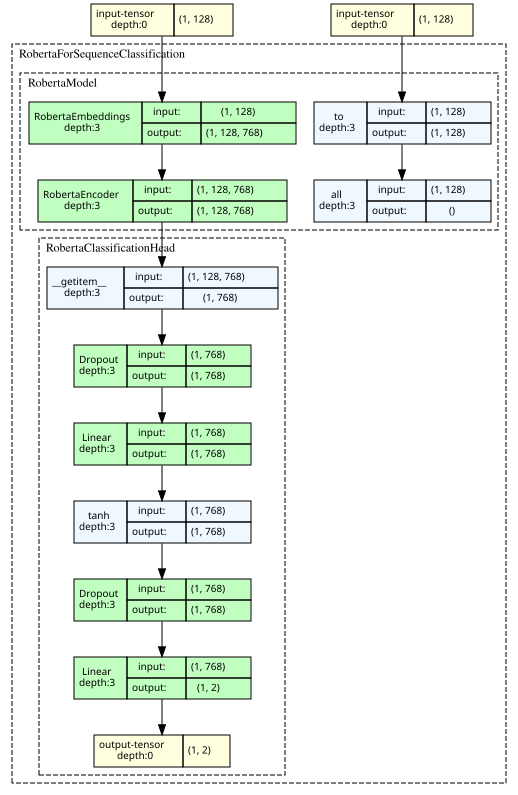

In [26]:
from torchview import draw_graph
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification

# Resolve model directory: prefer best run from comparison_df, fallback to default OUTPUT_DIR/final_model
if 'comparison_df' in globals() and isinstance(comparison_df, pd.DataFrame) and len(comparison_df) > 0:
    best_run_name = comparison_df.iloc[0]['run_name']
    model_dir = OUTPUT_DIR.parent / best_run_name / 'final_model'
else:
    model_dir = OUTPUT_DIR / 'final_model'

if not model_dir.exists():
    raise FileNotFoundError(f'Could not find saved model at: {model_dir}')

# Load model from saved checkpoint before plotting architecture
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device).eval()

class _TorchviewWrapper(nn.Module):
    def __init__(self, cls_model):
        super().__init__()
        self.roberta_model = cls_model

    def forward(self, input_ids, attention_mask):
        out = self.roberta_model(input_ids=input_ids, attention_mask=attention_mask)
        return out.logits

wrapped = _TorchviewWrapper(model).to(device).eval()

# Standard professional input shape in the diagram: (1, 128)
dummy_input_ids = torch.zeros((1, 128), dtype=torch.long).to(device)
dummy_mask = torch.ones((1, 128), dtype=torch.long).to(device)

graph = draw_graph(
    wrapped,
    input_data=(dummy_input_ids, dummy_mask),
    graph_name='RoBERTa_Subjectivity_Architecture',
    expand_nested=True,
    depth=3,
    device=device,
    hide_inner_tensors=True,
    hide_module_functions=False,
    save_graph=True,
    filename='roberta_subjectivity_architecture_final',
)

print('Loaded model from:', model_dir)
print('Graph saved as: roberta_subjectivity_architecture_final')
graph.visual_graph